## K-Means Clustering on Iris Dataset
This notebook demonstrates the application of K-Means clustering to the Iris dataset. We will load the data, preprocess it, apply the clustering algorithm, and visualize the results.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Import Libraries
We start by importing all the necessary libraries for data manipulation, visualization, and machine learning tasks. numpy and pandas for data handling, matplotlib and seaborn for plotting, sklearn.datasets to load the Iris dataset, StandardScaler for feature scaling, and KMeans for the clustering algorithm.

In [2]:
df = load_iris(as_frame=True).frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2. Load the Iris Dataset
Here, we load the famous Iris dataset, which is commonly used for classification and clustering examples. The dataset contains measurements of sepal length, sepal width, petal length, and petal width for three species of Iris flowers. We load it into a pandas DataFrame and display its head to get a glimpse of the data.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


## 3. Data Overview
The df.info() method provides a concise summary of the DataFrame, including the number of entries, the number of columns, non-null values for each column, and data types. This helps us quickly identify any missing values or incorrect data types.

In [4]:
X = df[['sepal length (cm)', 'sepal width (cm)']]
X.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


## 4. Feature Selection
For this K-Means clustering example, we will select only 'sepal length (cm)' and 'sepal width (cm)' as our features. This creates a new DataFrame X containing only these two columns, which will be used for clustering.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 5. Feature Scaling
K-Means clustering is sensitive to the scale of the features. To ensure that all features contribute equally to the distance calculations, we use StandardScaler to standardize the features. This transforms the data so that it has a mean of 0 and a standard deviation of 1.

In [6]:
kmeans = KMeans(n_clusters=3,
                init='k-means++',
                max_iter=400,
                random_state=42)

### 6. Initialize K-Means Model

We initialize the K-Means model with the following parameters:
- `n_clusters=3`: We expect three clusters, corresponding to the three species of Iris flowers.
- `init='k-means++'`: This is a smart initialization technique that helps to converge faster and avoid suboptimal solutions.
- `max_iter=400`: The maximum number of iterations for the algorithm to run.
- `random_state=42`: For reproducibility of results.

In [7]:
kmeans.fit(X_scaled)

KMeans(max_iter=400, n_clusters=3, random_state=42)

### 7. Fit the K-Means Model

Now, we fit the K-Means model to our scaled data `X_scaled`. The algorithm will iterate to find the optimal cluster centroids and assign each data point to a cluster.

In [8]:
print(kmeans.labels_[:80])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 1 2 2 2 2 2 2 2 2 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1
 0 0 0 0 1 1]


### 8. Inspect Cluster Labels

After fitting the model, `kmeans.labels_` contains the cluster assignment for each data point. We print the first 80 labels to see how the data points have been grouped into the 3 clusters.

In [9]:
df['clusters'] = kmeans.labels_
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,clusters
0,5.1,3.5,1.4,0.2,0,2
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,2
3,4.6,3.1,1.5,0.2,0,2
4,5.0,3.6,1.4,0.2,0,2


### 9. Add Cluster Labels to DataFrame

To better analyze and visualize the results, we add the generated `clusters` column back to our original DataFrame `df`. This allows us to see which cluster each original data point belongs to.

### 10. Visualize K-Means Clustering

Finally, we visualize the clustering results using a scatter plot. The x-axis represents 'sepal length (cm)', and the y-axis represents 'sepal width (cm)'. Each point is colored according to its assigned cluster (`hue=df['clusters']`), allowing us to see the distinct groups identified by the K-Means algorithm.

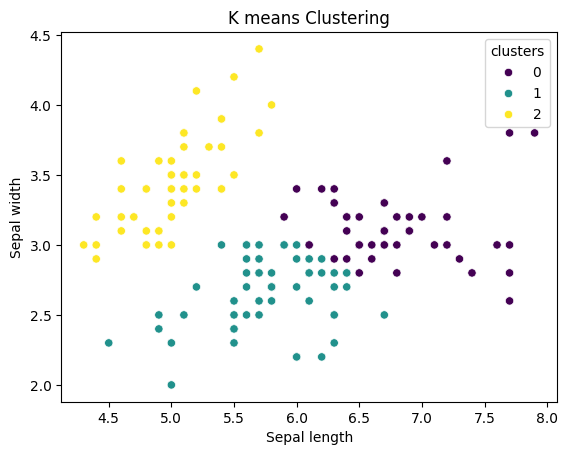

In [10]:
sns.scatterplot(
    x = df['sepal length (cm)'],
    y = df['sepal width (cm)'],
    hue=df['clusters'],
    palette='viridis'
)

plt.title("K means Clustering")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.show()

### 11. What is Inertia?

**Inertia** in K-Means clustering is like a measure of how 'tight' or 'compact' our clusters are. Think of it as the sum of how far each point is from the center of its own cluster. A smaller inertia value means that the points within each cluster are generally closer to their cluster's center, which usually suggests a better clustering result. However, it's important to remember that inertia will always decrease as you add more clusters, so we often use it with other methods to find the *best* number of clusters.

In [11]:
print(f"Inertia: {kmeans.inertia_}")

Inertia: 102.62862638978044


### 12. Inertia vs. SSE (Sum of Squared Errors)

Is Inertia similar to **SSE**? **Yes, they are the exact same thing!**

In the context of K-Means:
- **SSE** stands for Sum of Squared Errors. It calculates the error by squaring the distance between each point and its assigned cluster center.
- **Inertia** is simply the name that the `scikit-learn` library (and the K-Means algorithm in general) uses for that SSE value.

So, if your teacher asks for the 'SSE' of your clusters, you can just look at the `inertia_` value! Both tell you how much the data points 'deviate' from their centers.